# 📊 Generate Output Notebook (Final - IEEE Ready)

This notebook:
- Cleans and processes research data
- Generates IEEE-ready tables
- Produces advanced analysis graphs
- Exports LaTeX tables


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

## 📂 Load Dataset

In [3]:
df = pd.read_csv('research_data.csv')
df.columns = df.columns.str.strip()
df.head()

,id,username,filename,algorithm,size_kb,latency_ms,packets_lost,real_latency_ms,data_type,clumsy_lag_ms,clumsy_drop_pct
0,1,AutoBot_Text_IoT,Text_IoT_data.bin,Hybrid PQC,3.04,19.55,0,164.20,Text_IoT,0.0,0.0
1,2,AutoBot_Text_IoT,Text_IoT_data.bin,Hybrid PQC,3.02,19.53,0,96.26,Text_IoT,0.0,0.0
2,3,AutoBot_Text_IoT,Text_IoT_data.bin,Hybrid PQC,3.03,19.54,0,94.80,Text_IoT,0.0,0.0
3,4,AutoBot_Text_IoT,Text_IoT_data.bin,Standard AES,2.77,17.77,0,118.81,Text_IoT,0.0,0.0
4,5,AutoBot_Text_IoT,Text_IoT_data.bin,Standard AES,2.77,17.77,0,109.16,Text_IoT,0.0,0.0


## 🧹 Data Cleaning

In [4]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

df['latency_ms'] = df['latency_ms'].round(2)
df['real_latency_ms'] = df['real_latency_ms'].round(2)

## 📊 Table 1: Algorithm Performance

In [5]:
summary = df.groupby('algorithm').agg({
    'latency_ms': ['mean','std'],
    'real_latency_ms':'mean',
    'packets_lost':'mean',
    'size_kb':'mean'
}).reset_index()

summary.columns = ['Algorithm','Sim_Latency_Mean','Sim_Latency_STD','Real_Latency_Mean','Avg_Packet_Loss','Avg_File_Size']
summary

,Algorithm,Sim_Latency_Mean,Sim_Latency_STD,Real_Latency_Mean,Avg_Packet_Loss,Avg_File_Size
0,Hybrid PQC,1862.518082,3308.332212,2487.060755,4.481731,1231.678798
1,Standard AES,1798.520321,3038.315780,2504.093855,1.653238,1783.520321


In [6]:
summary.to_latex('tables/table_performance.tex', index=False, float_format='%.2f')

## 📊 Table 2: Payload Latency

In [7]:
payload_table = df.groupby(['data_type','algorithm'])['real_latency_ms'].mean().reset_index()
payload_table

,data_type,algorithm,real_latency_ms
0,Document_PDF,Hybrid PQC,1360.564896
1,Document_PDF,Standard AES,1388.958486
2,HD_Video,Standard AES,0.000000
3,High_Res_Image,Hybrid PQC,6454.800754
4,High_Res_Image,Standard AES,6020.806551
5,Manual_Web_Upload,Hybrid PQC,900.500000
6,Text_IoT,Hybrid PQC,1211.652380
7,Text_IoT,Standard AES,1235.128078


In [8]:
payload_table.to_latex('tables/table_payload.tex', index=False, float_format='%.2f')

## 📊 Table 3: Packet Loss Stats

In [9]:
packet_table = df.groupby('algorithm')['packets_lost'].describe()[['mean','max','min']]
packet_table

,mean,max,min
algorithm,,,
Hybrid PQC,4.481731,510.0,0.0
Standard AES,1.653238,823.0,0.0


In [10]:
packet_table.to_latex('tables/table_packet_loss.tex', float_format='%.2f')

## 📈 Graphs (Formatted - Publication Ready)

## Graph 1: Average Latency

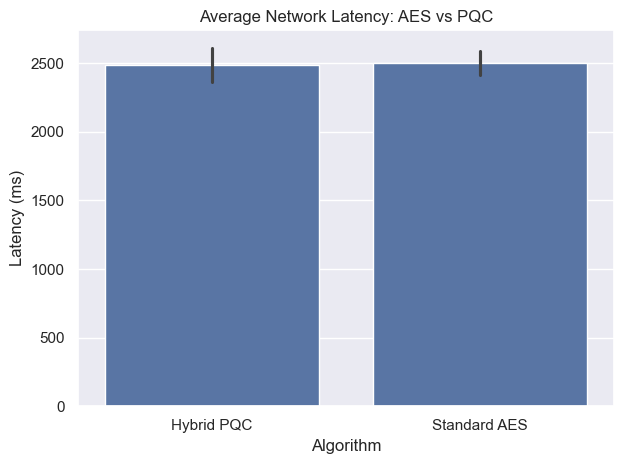

In [11]:
plt.figure()
sns.barplot(data=df, x='algorithm', y='real_latency_ms')
plt.title('Average Network Latency: AES vs PQC')
plt.xlabel('Algorithm')
plt.ylabel('Latency (ms)')
plt.tight_layout()
plt.savefig('charts/fig1_latency_bar.png', dpi=300)
plt.show()

## Graph 2: Latency Scaling

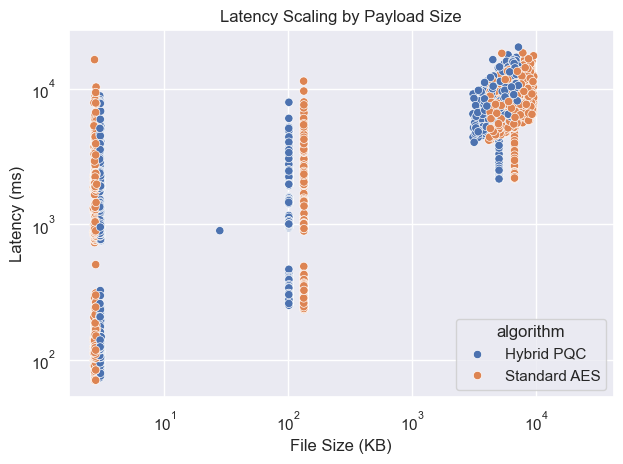

In [12]:
plt.figure()
sns.scatterplot(data=df, x='size_kb', y='real_latency_ms', hue='algorithm')
plt.xscale('log'); plt.yscale('log')
plt.xlabel('File Size (KB)'); plt.ylabel('Latency (ms)')
plt.title('Latency Scaling by Payload Size')
plt.tight_layout()
plt.savefig('charts/fig2_latency_scatter.png', dpi=300)
plt.show()

## Graph 3: Packet Loss

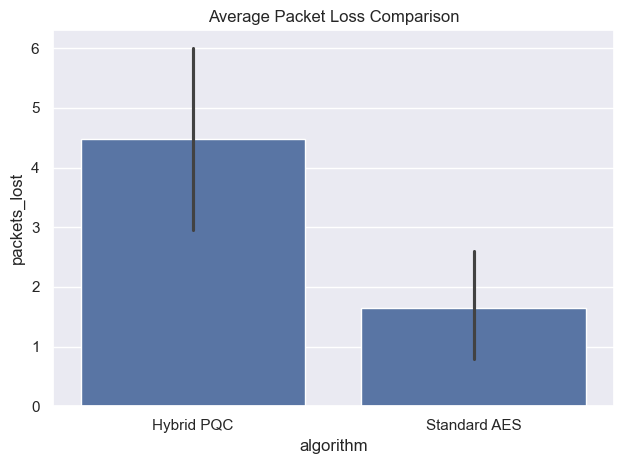

In [13]:
plt.figure()
sns.barplot(data=df, x='algorithm', y='packets_lost')
plt.title('Average Packet Loss Comparison')
plt.tight_layout()
plt.savefig('charts/fig3_packet_loss.png', dpi=300)
plt.show()

## Graph 4: AI Routing Distribution

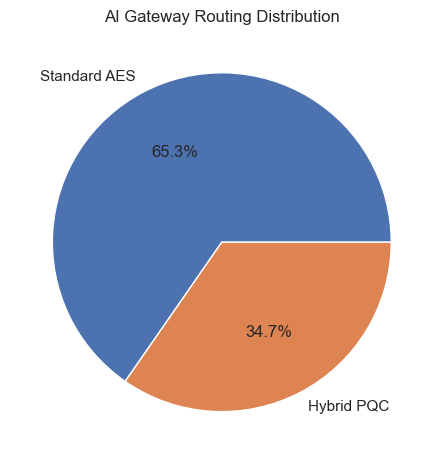

In [14]:
counts = df['algorithm'].value_counts()
plt.figure()
plt.pie(counts, labels=counts.index, autopct='%1.1f%%')
plt.title('AI Gateway Routing Distribution')
plt.tight_layout()
plt.savefig('charts/fig4_ai_distribution.png', dpi=300)
plt.show()

## Graph 5: Latency Variance

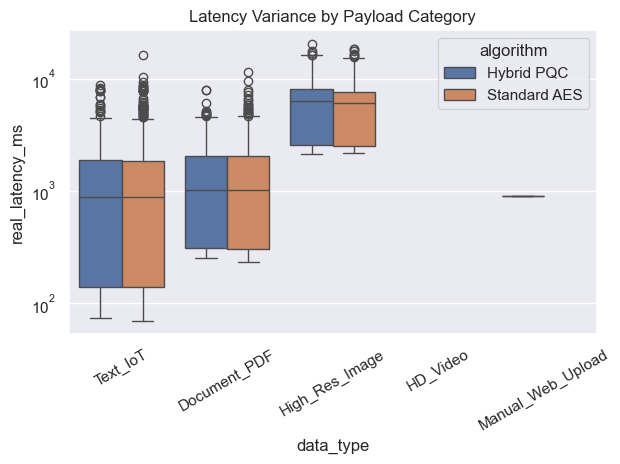

In [15]:
plt.figure()
sns.boxplot(data=df, x='data_type', y='real_latency_ms', hue='algorithm')
plt.yscale('log'); plt.xticks(rotation=30)
plt.title('Latency Variance by Payload Category')
plt.tight_layout()
plt.savefig('charts/fig5_latency_variance.png', dpi=300)
plt.show()

## Graph 6: ECDF

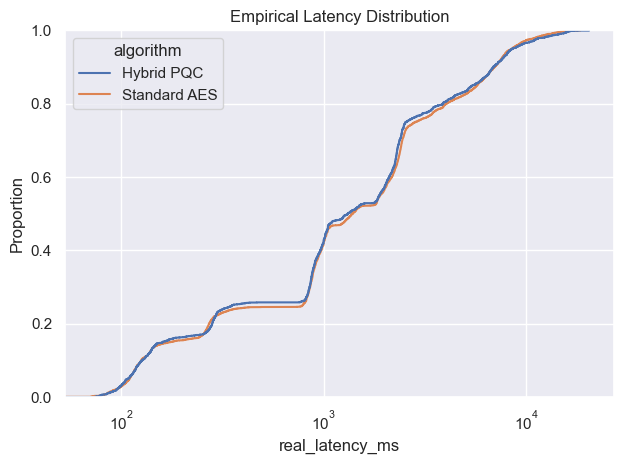

In [16]:
plt.figure()
sns.ecdfplot(data=df, x='real_latency_ms', hue='algorithm')
plt.xscale('log')
plt.title('Empirical Latency Distribution')
plt.tight_layout()
plt.savefig('charts/fig6_latency_ecdf.png', dpi=300)
plt.show()

## Graph 7: Throughput

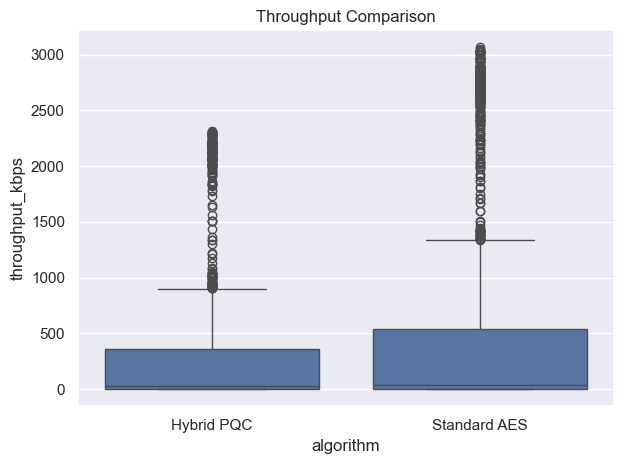

In [17]:
df['throughput_kbps'] = df['size_kb'] / (df['real_latency_ms']/1000)
plt.figure()
sns.boxplot(data=df, x='algorithm', y='throughput_kbps')
plt.title('Throughput Comparison')
plt.tight_layout()
plt.savefig('charts/fig7_throughput.png', dpi=300)
plt.show()

## Graph 8: Security vs Performance

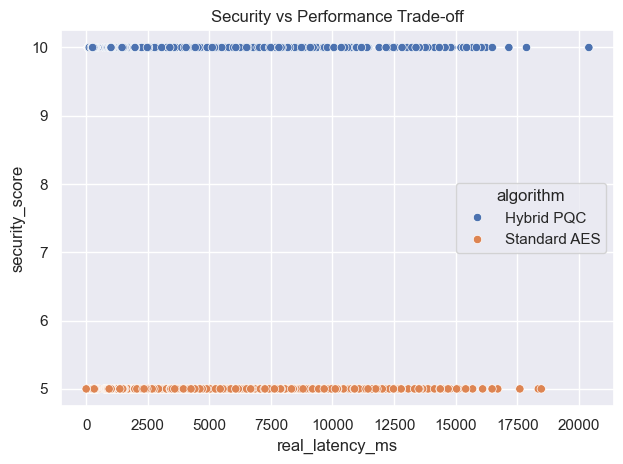

In [18]:
df['security_score'] = df['algorithm'].apply(lambda x: 10 if 'PQC' in x else 5)
plt.figure()
sns.scatterplot(data=df, x='real_latency_ms', y='security_score', hue='algorithm')
plt.title('Security vs Performance Trade-off')
plt.tight_layout()
plt.savefig('charts/fig8_security_vs_performance_tradeoff.png', dpi=300)
plt.show()